# Return / Log-Return Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('../data/processed_data.csv')

# Calculate log-returns
# We use log-returns for the analysis because they are more stable and easier to interpret
log_returns = np.log(df / df.shift(1))
log_returns = log_returns.dropna()

# Descriptive statistics
stats = log_returns.agg(['mean', 'std', 'skew', 'kurtosis']).T
stats

,mean,std,skew,kurtosis
gurkor,0.000174,0.003952,-0.096609,3.408978
guitars,0.000242,0.014966,-0.005055,5.649241
slingshots,0.000237,0.014915,-0.415221,6.243814
stocks,-0.000031,0.014915,-0.139732,0.097082
sugar,-0.000008,0.015097,-0.270640,11.476589
water,0.000150,0.003507,-0.239211,2.290449
tranquillity,-0.000014,0.012782,-0.271841,2.896865


1. Mean (expected returns) is very close to zero for each series. This is copnsistent with financial timeseries. There is no strong drift in returns.
2. A clear distinction in volatility levels is observed, with gurkor and water exhibiting significantly lower volatility compared to assets such as guitars, slingshots, and sugar.
3. Most return distributions exhibit slight negative skewness, indicating a tendency for more extreme negative returns than positive ones.
4. Most assets exhibit excess kurtosis, indicating fat-tailed distributions and a higher likelihood of extreme events compared to the normal distribution. This is particularly pronounced for sugar, which shows very high kurtosis. In contrast, the stock series appears closer to normally distributed, with low kurtosis and a near-linear QQ-plot.

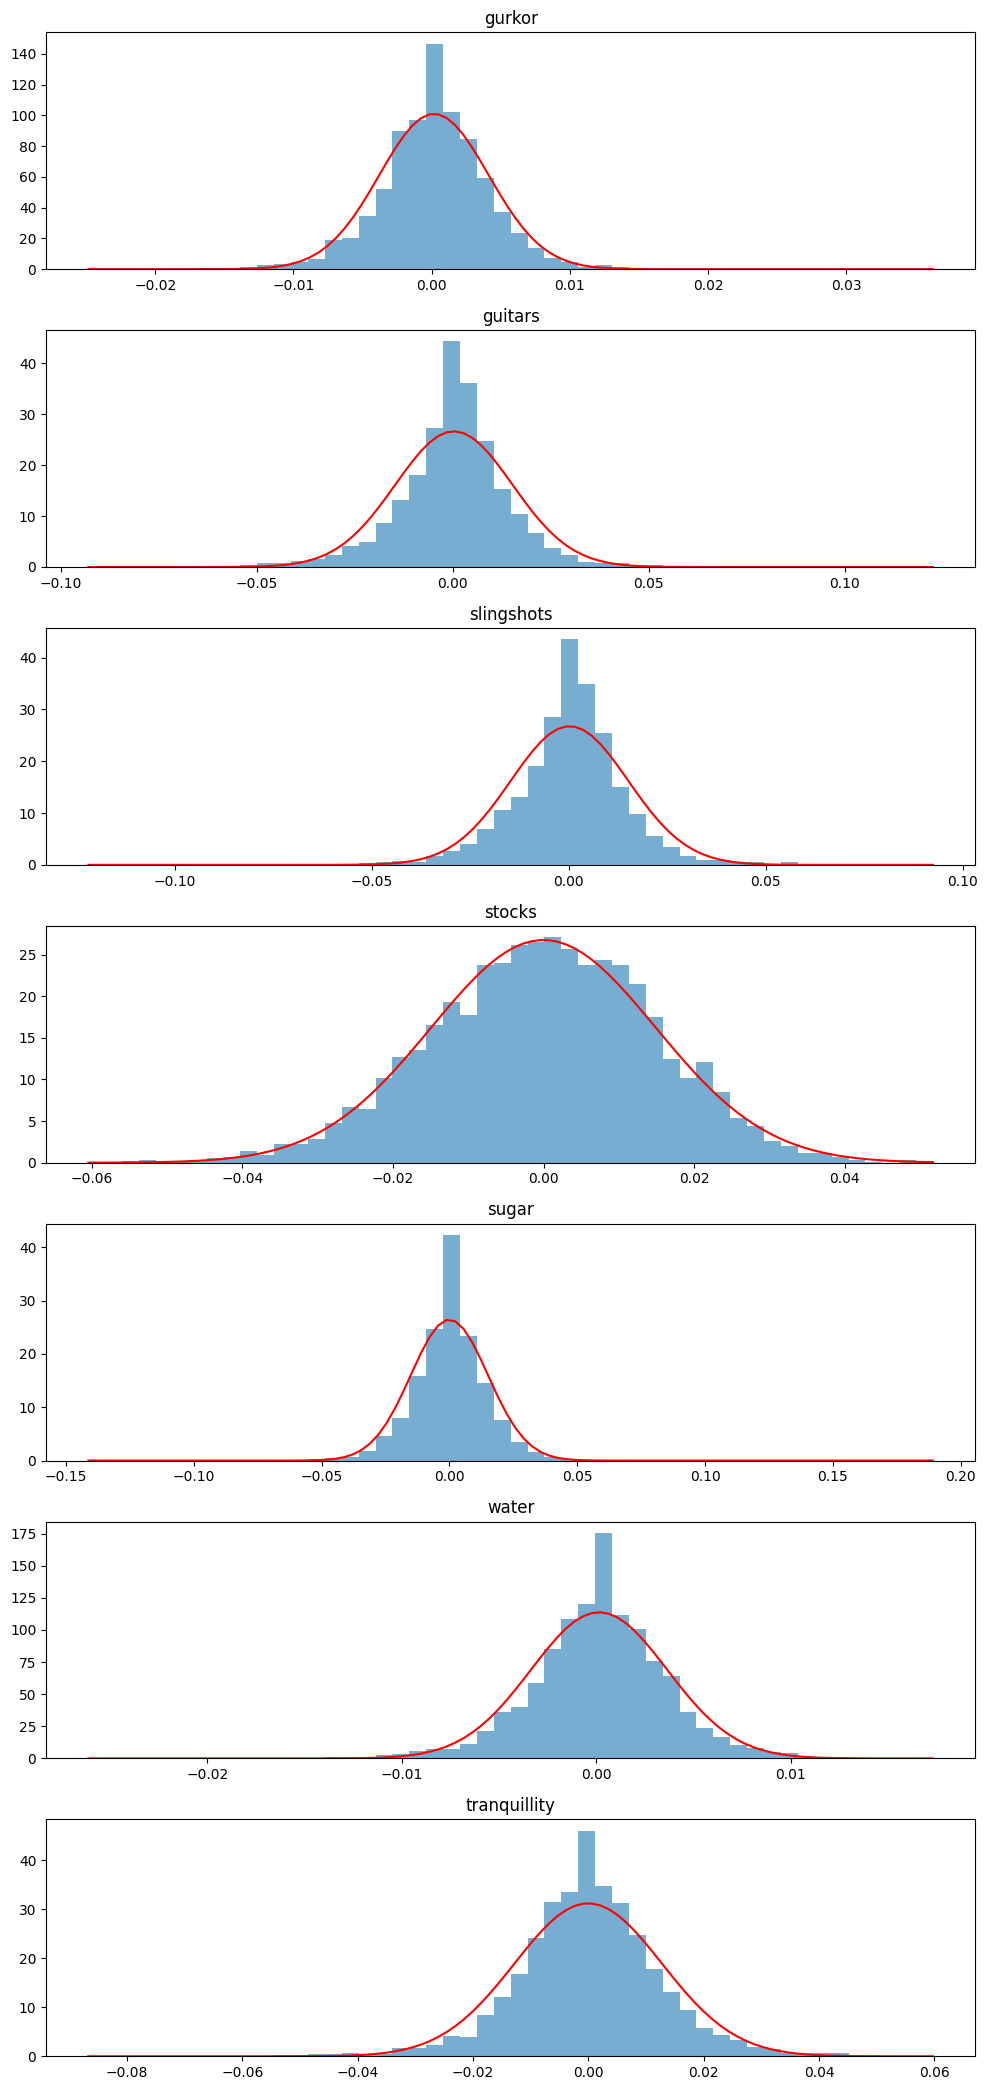

In [3]:
# Histogram and normal fit

import scipy.stats as stats
import matplotlib.pyplot as plt

n = len(log_returns.columns)
fig, axes = plt.subplots(n, 1, figsize=(10, 3*n))

if n == 1:
    axes = [axes]

for ax, col in zip(axes, log_returns.columns):
    data = log_returns[col].dropna()
    
    ax.hist(data, bins=50, density=True, alpha=0.6)
    
    # normal fit
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r')
    
    ax.set_title(col)

plt.tight_layout()
plt.show()

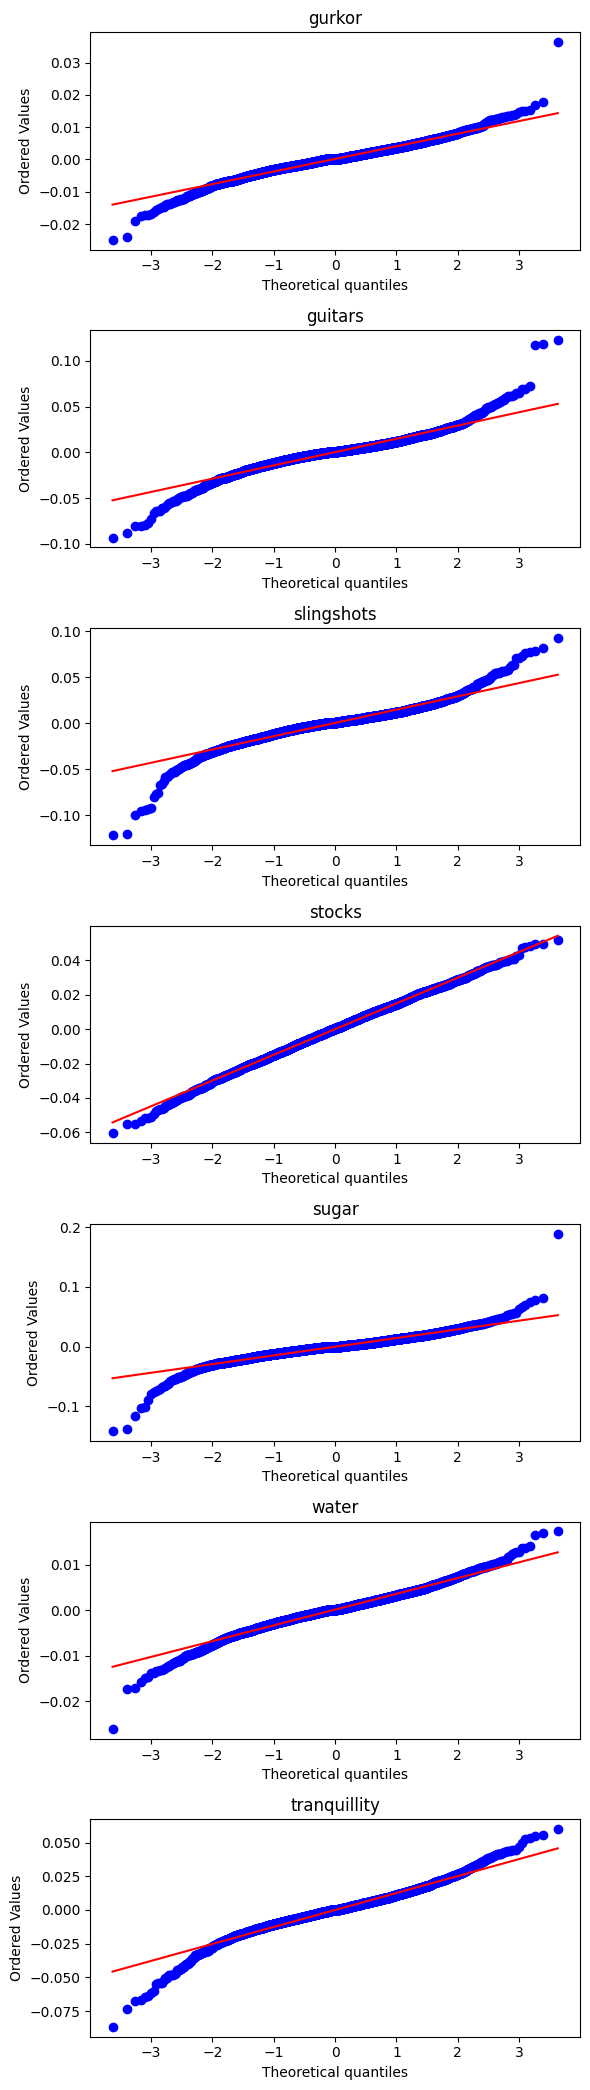

In [4]:
# QQ-plot

import scipy.stats as stats

n = len(log_returns.columns)
fig, axes = plt.subplots(n, 1, figsize=(6, 3*n))

if n == 1:
    axes = [axes]

for ax, col in zip(axes, log_returns.columns):
    stats.probplot(log_returns[col].dropna(), dist="norm", plot=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Histogram and QQ-plot analysis confirm that most return series deviate from normality, particularly in the tails. Several series display clear heavy-tailed behavior, with extreme observations far exceeding those predicted by a normal distribution.

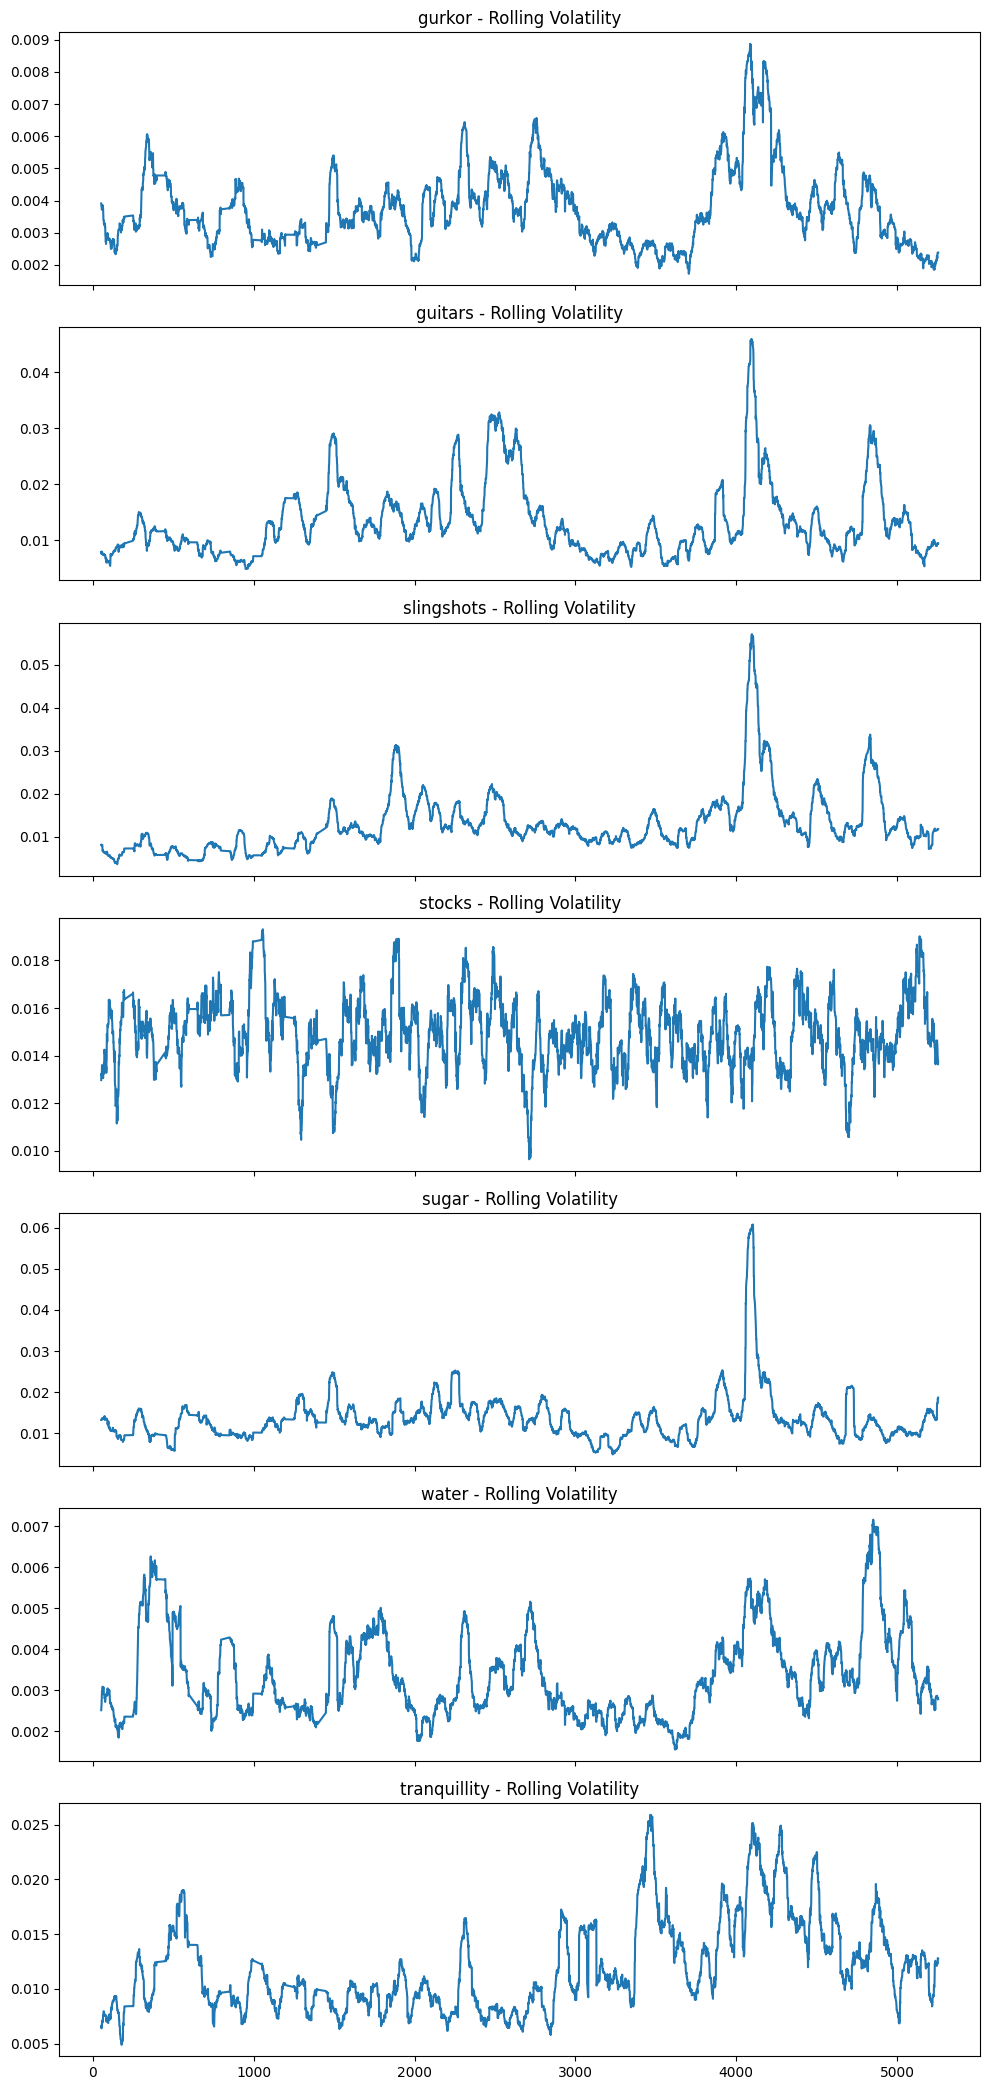

In [5]:
rolling_vol = log_returns.rolling(50).std()

n = len(rolling_vol.columns)
fig, axes = plt.subplots(n, 1, figsize=(10, 3*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, col in zip(axes, rolling_vol.columns):
    ax.plot(rolling_vol[col])
    ax.set_title(f"{col} - Rolling Volatility")

plt.tight_layout()
plt.show()

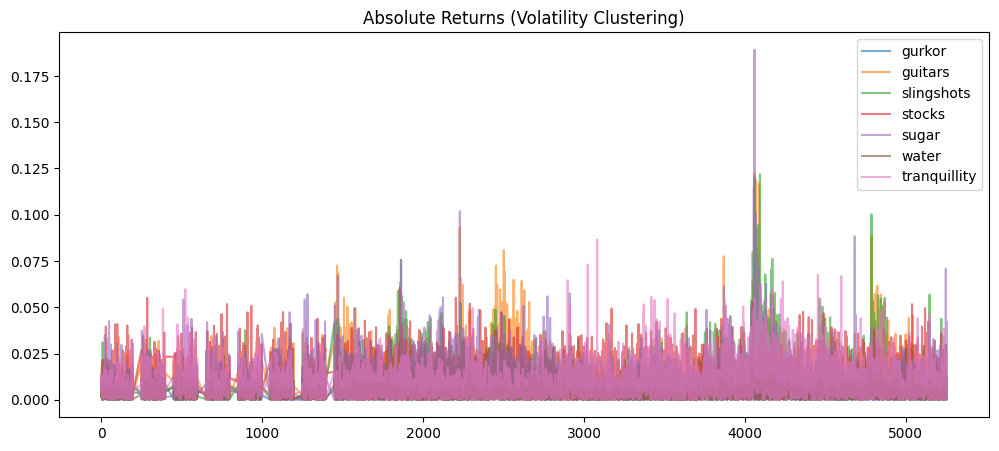

In [6]:
abs_returns = log_returns.abs()

plt.figure(figsize=(12,5))
for col in abs_returns.columns:
    plt.plot(abs_returns[col], alpha=0.6, label=col)

plt.legend()
plt.title("Absolute Returns (Volatility Clustering)")
plt.show()

## Analysis

The return series exhibit several well-known stylized facts of financial time series, including near-zero mean returns, heavy tails, and volatility clustering. These properties indicate that simple Gaussian models are insufficient to fully capture the dynamics of the data.

The presence of fat tails and volatility clustering suggests that models assuming constant variance may be inadequate. This has important implications for both interpolation and forecasting, where models capable of capturing time-varying volatility may perform better.